In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("retail_store_sales.csv")

In [3]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [4]:
df.tail()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True
12574,TXN_2407494,CUST_23,Food,Item_9_FOOD,17.0,3.0,51.0,Cash,Online,2022-08-06,NaN


In [5]:
df.shape

(12575, 11)

In [6]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


In [8]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

In [12]:
df['Transaction Date'].head()

0   2024-04-08
1   2023-07-23
2   2022-10-05
3   2022-05-07
4   2022-10-02
Name: Transaction Date, dtype: datetime64[us]

In [13]:
df.describe()

,Price Per Unit,Quantity,Total Spent,Transaction Date
count,11966.000000,11971.000000,11971.000000,12575
mean,23.365912,5.536380,129.652577,2023-07-12 20:23:41.105367
min,5.000000,1.000000,5.000000,2022-01-01 00:00:00
25%,14.000000,3.000000,51.000000,2022-09-30 00:00:00
50%,23.000000,6.000000,108.500000,2023-07-13 00:00:00
75%,33.500000,8.000000,192.000000,2024-04-24 00:00:00
max,41.000000,10.000000,410.000000,2025-01-18 00:00:00
std,10.743519,2.857883,94.750697,NaN


In [14]:
df['Total Spent'].sum()

np.float64(1552071.0)

In [15]:
category_sales = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False)
category_sales

Category
Butchers                              208118.0
Electric household essentials         203813.5
Beverages                             197047.5
Furniture                             195310.0
Food                                  194812.0
Computers and electric accessories    190692.5
Patisserie                            182165.5
Milk Products                         180112.0
Name: Total Spent, dtype: float64

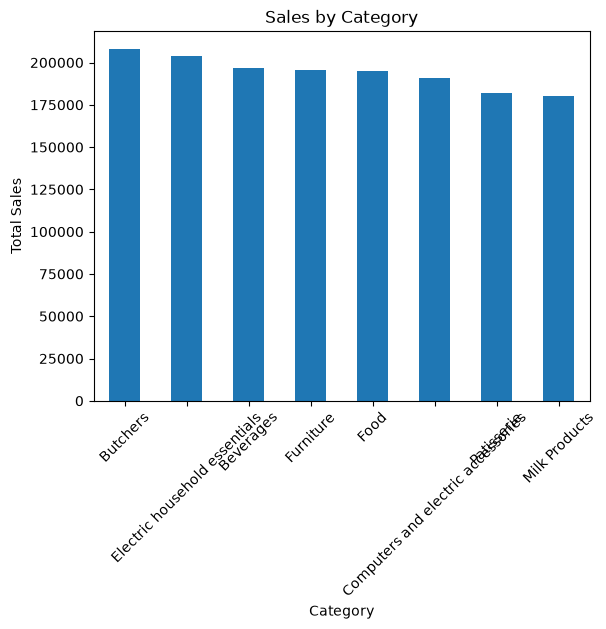

In [16]:
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [17]:
location_sales = df.groupby('Location')['Total Spent'].sum().sort_values(ascending=False)
location_sales

Location
Online      791401.0
In-store    760670.0
Name: Total Spent, dtype: float64

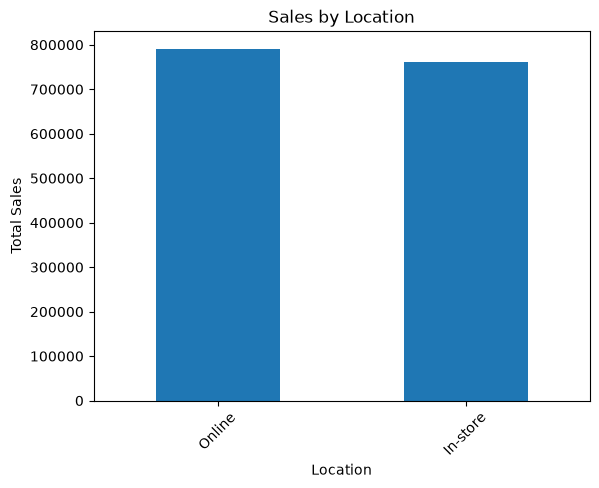

In [18]:
location_sales.plot(kind='bar')
plt.title('Sales by Location')
plt.xlabel('Location')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [19]:
product_sales = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False)
product_sales.head(10)



Item
Item_2_BEV      676.0
Item_16_MILK    627.0
Item_25_FUR     616.0
Item_19_MILK    589.0
Item_5_FUR      581.0
Item_13_FOOD    581.0
Item_1_MILK     578.0
Item_11_MILK    574.0
Item_11_FUR     573.0
Item_14_FOOD    566.0
Name: Quantity, dtype: float64

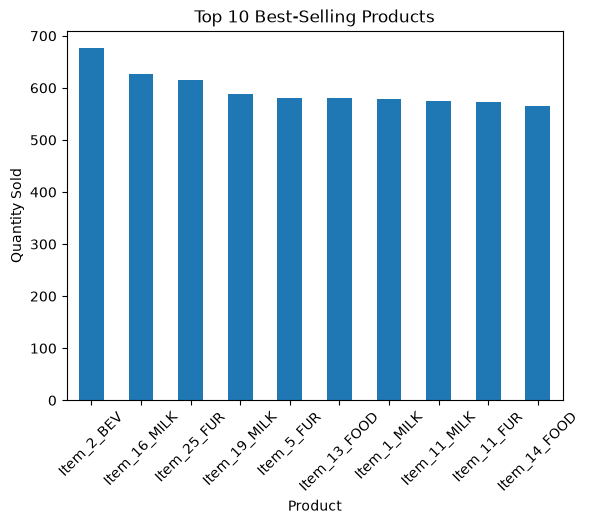

In [20]:
product_sales.head(10).plot(kind='bar')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()

In [21]:
payment = df.groupby('Payment Method')['Total Spent'].sum()
payment

Payment Method
Cash              537710.0
Credit Card       507082.0
Digital Wallet    507279.0
Name: Total Spent, dtype: float64

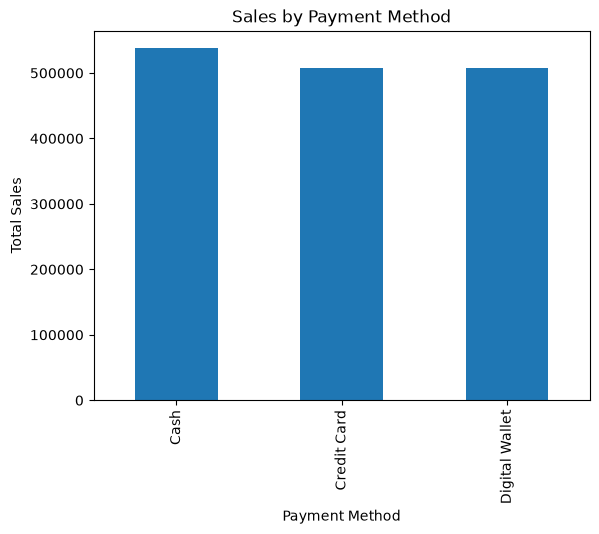

In [22]:
payment.plot(kind='bar')
plt.title('Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales')
plt.show()

In [23]:
df['Month'] = df['Transaction Date'].dt.to_period('M')

In [24]:
monthly_sales = df.groupby('Month')['Total Spent'].sum()
monthly_sales

Month
2022-01    52911.5
2022-02    43325.5
2022-03    40996.0
2022-04    40442.0
2022-05    40347.5
2022-06    42576.0
2022-07    44471.5
2022-08    41333.5
2022-09    46113.5
2022-10    38355.0
2022-11    41256.5
2022-12    38201.0
2023-01    48052.5
2023-02    39214.5
2023-03    38534.5
2023-04    38905.5
2023-05    40480.5
2023-06    42474.0
2023-07    45632.5
2023-08    38592.0
2023-09    41069.0
2023-10    38322.0
2023-11    37014.0
2023-12    43021.0
2024-01    47908.5
2024-02    37145.0
2024-03    42861.5
2024-04    46271.0
2024-05    43766.5
2024-06    44721.0
2024-07    41405.0
2024-08    43362.0
2024-09    42161.5
2024-10    42736.5
2024-11    44076.0
2024-12    48466.5
2025-01    25548.5
Freq: M, Name: Total Spent, dtype: float64

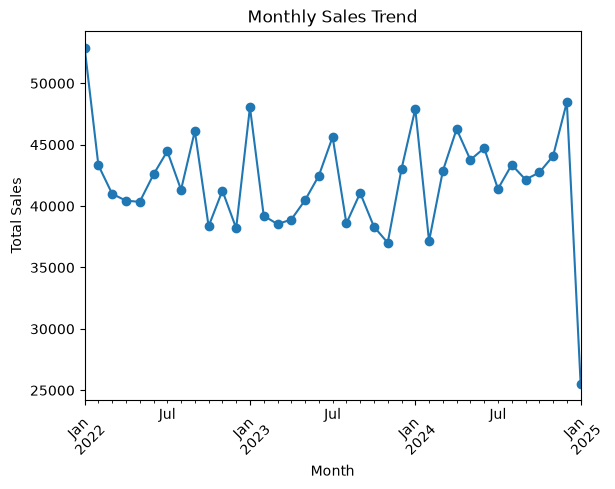

In [25]:
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [26]:
df.groupby('Discount Applied')['Total Spent'].agg(['count', 'sum', 'mean'])

,count,sum,mean
Discount Applied,,,
False,3964,515135.0,129.953330
True,4019,524443.5,130.491043


In [27]:
customer_sales = df.groupby('Customer ID')['Total Spent'].sum().sort_values(ascending=False)

customer_sales.head(10)

Customer ID
CUST_24    68452.0
CUST_08    67351.5
CUST_05    66974.5
CUST_16    65570.5
CUST_13    65037.0
CUST_23    64507.0
CUST_10    63155.5
CUST_15    63117.5
CUST_21    62933.0
CUST_02    62046.5
Name: Total Spent, dtype: float64

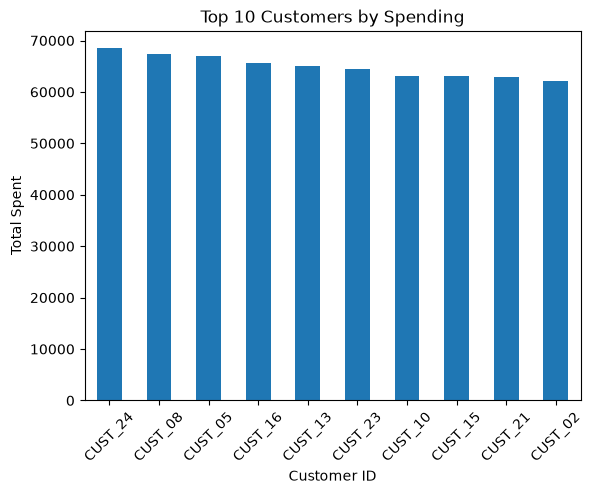

In [28]:
customer_sales.head(10).plot(kind='bar')
plt.title('Top 10 Customers by Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Spent')
plt.xticks(rotation=45)
plt.show()